In [1]:


import pandas as pd
import numpy as np
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score, log_loss
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
# Association Rules
from mlxtend.frequent_patterns import apriori, association_rules

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 1000)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
print("="*70)
print("1. DATA LOADING & SIZE ANALYSIS")
print("="*70)

# Load data
df = pd.read_csv('Phone buying behavior 2026 (Responses) - Form responses 1.csv')
print('sample data')


print(df.head(5))

# Size analysis
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"Duplicate Rows: {df.duplicated().sum()}")

# Column list
print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

1. DATA LOADING & SIZE ANALYSIS
sample data
             Timestamp Birth Year  Gender Current Brand Ownership Duration                  Top Priorities Information Source    Purchase Preference Previous Brand  Loyalty (1-5) Other Devices?  AI Features (1-5) Foldable Interest       Max Budget  After-Sales (1-5)
0  01/01/2026 08:15:22       2004  Female         Redmi            2 years  Camera, Battery, Affordability      Friend/Family  One-time full payment           Vivo              2             No                  4             Maybe  around 15 lakhs                  4
1  01/01/2026 09:32:45       2003  Female       Samsung           3 months                          Camera      Friend/Family  One-time full payment        Samsung              4             No                  5               Yes   above 20 lakhs                  5
2  01/01/2026 10:47:12       2005  Female         Redmi           3 months  Battery, Gaming, Affordability      Friend/Family  One-time full payment       

In [3]:
print("="*70)
print("2. DATA TYPES & NULL ANALYSIS")
print("="*70)

# Data types
print("\nDATA TYPES:")
print(df.dtypes)

# Null values
null_counts = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df)) * 100

null_df = pd.DataFrame({
    'Column': df.columns,
    'Null Count': null_counts.values,
    'Null %': null_percentage.values
})

print("\nNULL VALUES:")
print(null_df[null_df['Null Count'] > 0] if null_df['Null Count'].sum() > 0 else "  ✓ No missing values found")

# Data range for numerical columns
print("\nNUMERICAL RANGES:")
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    print(f"  {col}:")
    print(f"    Min: {df[col].min():.2f}")
    print(f"    Max: {df[col].max():.2f}")
    print(f"    Range: {df[col].max() - df[col].min():.2f}")

2. DATA TYPES & NULL ANALYSIS

DATA TYPES:
Timestamp                str
Birth Year               str
Gender                   str
Current Brand            str
Ownership Duration       str
Top Priorities           str
Information Source       str
Purchase Preference      str
Previous Brand           str
Loyalty (1-5)          int64
Other Devices?           str
AI Features (1-5)      int64
Foldable Interest        str
Max Budget               str
After-Sales (1-5)      int64
dtype: object

NULL VALUES:
            Column  Null Count    Null %
10  Other Devices?           2  0.363636

NUMERICAL RANGES:
  Loyalty (1-5):
    Min: 1.00
    Max: 5.00
    Range: 4.00
  AI Features (1-5):
    Min: 1.00
    Max: 5.00
    Range: 4.00
  After-Sales (1-5):
    Min: 1.00
    Max: 5.00
    Range: 4.00


In [4]:
print("="*70)
print("3. MULTI-VALUE COLUMNS & TEXT AGGREGATION")
print("="*70)

# =============================================
# DETECT MULTI-VALUE COLUMNS (FIXED)
# =============================================

multi_val_cols = []

# Fix 1: Include both 'object' and 'str' dtypes (removes pandas warning)
for col in df.select_dtypes(include=['object', 'str']).columns:
    # Fix 2: Only check string columns for commas
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
    
    if sample and isinstance(sample, str) and ',' in sample:
        multi_val_cols.append(col)
        print(f"\n✓ {col} contains comma-separated values")
        print(f"  Sample: {sample[:100]}...")  # Truncate long samples
        
        # Fix 3: Safely count unique values (handle unhashable types)
        try:
            unique_count = df[col].nunique()
            print(f"  Unique values: {unique_count}")
        except TypeError:
            # If column contains unhashable types (lists), convert to string first
            unique_count = df[col].astype(str).nunique()
            print(f"  Unique values (as strings): {unique_count}")

# =============================================
# CREATE PRIORITY_MERGED COLUMN (CRITICAL FIX)
# =============================================

# Step 1: Clean priority lists (handles both strings and lists)
def clean_priorities(priority_str):
    """Convert various input formats to a clean list of priorities."""
    if pd.isna(priority_str):
        return []
    
    # If already a list, clean each item
    if isinstance(priority_str, list):
        return [str(p).strip() for p in priority_str if p and str(p).strip()]
    
    # If string, split by comma
    if isinstance(priority_str, str):
        return [p.strip() for p in priority_str.split(',') if p.strip()]
    
    # Fallback: convert to string and try
    return [p.strip() for p in str(priority_str).split(',') if p.strip()]

df['Priority_List'] = df['Top Priorities'].apply(clean_priorities)

# Step 2: Merge similar priorities
merge_mapping = {
    'Camera': ['Camera', 'Camera/video resolution'],
    'Battery': ['Battery', 'Battery Life'],
    'Brand': ['Brand', 'Brand Image', 'Brand Image/Status'],
    'Gaming': ['Gaming', 'Gaming Performance'],
    'SOC': ['SOC', 'SOC(Like Snapdragon)', 'System On Chip (SOC)', 'CPU']
}

def merge_priority(p):
    """Merge variant priority names into standardized categories."""
    for merged, variations in merge_mapping.items():
        if p in variations:
            return merged
    return p

df['Priority_Merged'] = df['Priority_List'].apply(
    lambda priorities: [merge_priority(p) for p in priorities]
)

# Step 3: Priority Count
df['Priority_Count'] = df['Priority_List'].apply(len)

# Step 4: Analyze priorities
from collections import Counter

all_priorities = []
priority_combinations = []

for priorities in df['Priority_Merged']:
    all_priorities.extend(priorities)
    if priorities:
        priority_combinations.append(tuple(sorted(priorities)))

priority_counts = Counter(all_priorities)
combo_counts = Counter(priority_combinations)

# Step 5: Print Results
print("\n" + "="*70)
print("PRIORITY ANALYSIS (Text Aggregation)")
print("="*70)

print(f"\n  Total priority mentions: {len(all_priorities)}")
print(f"  Unique priorities: {len(priority_counts)}")
print(f"  Avg priorities per person: {len(all_priorities)/len(df):.2f}")

print("\n  Most Common Priorities:")
for p, count in priority_counts.most_common(5):
    print(f"    {p}: {count} ({count/len(df)*100:.1f}%)")

print("\n  Most Common Priority Combinations:")
for combo, count in combo_counts.most_common(5):
    combo_str = ', '.join(combo)
    print(f"    [{combo_str}]: {count} people ({count/len(df)*100:.1f}%)")

# Step 6: Additional Insights (Optional)
print("\n" + "="*70)
print("ADDITIONAL INSIGHTS")
print("="*70)

# People with no priorities
no_priority_count = (df['Priority_Count'] == 0).sum()
print(f"\n  People with no priorities: {no_priority_count} ({no_priority_count/len(df)*100:.1f}%)")

# People with many priorities
multi_priority_count = (df['Priority_Count'] >= 5).sum()
print(f"  People with 5+ priorities: {multi_priority_count} ({multi_priority_count/len(df)*100:.1f}%)")

# Show sample of merged priorities
print("\n  Sample of merged priorities (first 3 rows):")
for idx in range(min(3, len(df))):
    print(f"    Row {idx+1}: {df['Priority_Merged'].iloc[idx]}")

print("\n" + "="*70)
print(" ANALYSIS COMPLETE")
print("="*70)

3. MULTI-VALUE COLUMNS & TEXT AGGREGATION

✓ Top Priorities contains comma-separated values
  Sample: Camera, Battery, Affordability...
  Unique values: 70

PRIORITY ANALYSIS (Text Aggregation)

  Total priority mentions: 1217
  Unique priorities: 6
  Avg priorities per person: 2.21

  Most Common Priorities:
    Camera: 394 (71.6%)
    Battery: 329 (59.8%)
    Affordability: 147 (26.7%)
    Brand: 134 (24.4%)
    Gaming: 126 (22.9%)

  Most Common Priority Combinations:
    [Battery, Camera]: 102 people (18.5%)
    [Camera]: 49 people (8.9%)
    [Brand, Camera]: 48 people (8.7%)
    [Affordability, Battery, Camera]: 37 people (6.7%)
    [Battery, Brand, Camera]: 37 people (6.7%)

ADDITIONAL INSIGHTS

  People with no priorities: 0 (0.0%)
  People with 5+ priorities: 2 (0.4%)

  Sample of merged priorities (first 3 rows):
    Row 1: ['Camera', 'Battery', 'Affordability']
    Row 2: ['Camera']
    Row 3: ['Battery', 'Gaming', 'Affordability']

 ANALYSIS COMPLETE


In [5]:
print("="*70)
print("4. AGE & DEMOGRAPHIC ANALYSIS")
print("="*70)

# Clean birth year
def clean_birth_year(year):
    if pd.isna(year):
        return np.nan
    year_str = str(year).strip()
    digits = re.findall(r'\d+', year_str)
    if not digits:
        return np.nan
    for d in digits:
        if len(d) == 4:
            return int(d)
    return int(digits[0])

df['Birth_Year_Cleaned'] = df['Birth Year'].apply(clean_birth_year)
df['Age'] = 2026 - df['Birth_Year_Cleaned']

# Remove invalid ages
df = df[df['Age'].between(10, 80)].copy()

# Age statistics
print("AGE STATISTICS:")
print(df['Age'].describe())

# Age groups
def bin_age(age):
    if age <= 20: return '18-20'
    elif age <= 22: return '21-22'
    elif age <= 24: return '23-24'
    elif age <= 30: return '25-30'
    else: return '31+'

df['Age_Binned'] = df['Age'].apply(bin_age)

print("\nAGE GROUP DISTRIBUTION:")
print(df['Age_Binned'].value_counts().sort_index())

# Gender comparison
print("\nGENDER COMPARISON:")
male = df[df['Gender'] == 'Male']
female = df[df['Gender'] == 'Female']

print(f"Male (n={len(male)}):")
print(f"  Avg Age: {male['Age'].mean():.1f}")
print(f"  Avg Loyalty: {male['Loyalty (1-5)'].mean():.2f}")

print(f"\nFemale (n={len(female)}):")
print(f"  Avg Age: {female['Age'].mean():.1f}")
print(f"  Avg Loyalty: {female['Loyalty (1-5)'].mean():.2f}")

4. AGE & DEMOGRAPHIC ANALYSIS
AGE STATISTICS:
count    550.000000
mean      22.814545
std        5.152163
min       19.000000
25%       21.000000
50%       22.000000
75%       23.000000
max       54.000000
Name: Age, dtype: float64

AGE GROUP DISTRIBUTION:
Age_Binned
18-20     81
21-22    315
23-24    118
25-30     11
31+       25
Name: count, dtype: int64

GENDER COMPARISON:
Male (n=162):
  Avg Age: 22.3
  Avg Loyalty: 3.70

Female (n=388):
  Avg Age: 23.0
  Avg Loyalty: 3.74


In [6]:
print("="*70)
print("5. FEATURE ENGINEERING")
print("="*70)

# 5.1 Convert Budget
def convert_budget(value):
    if pd.isna(value):
        return np.nan
    value = str(value).lower().strip()
    if 'above' in value or 'over' in value:
        if '20' in value: return 22.0
    if '20' in value: return 20.0
    if '15' in value: return 15.0
    if '10' in value: return 10.0
    if '8' in value: return 8.0
    if '6' in value: return 6.0
    if 'affordable' in value:
        return np.nan
    return np.nan

df['Max_Budget_Lakhs'] = df['Max Budget'].apply(convert_budget)

print("Budget conversion sample:")
print(df[['Max Budget', 'Max_Budget_Lakhs']].drop_duplicates().head(10))

# 5.2 Convert Ownership Duration
def convert_duration(value):
    if pd.isna(value):
        return np.nan
    value = str(value).lower().strip()
    try:
        if 'year' in value:
            num = re.search(r'\d+(?:\.\d+)?', value)
            return float(num.group()) * 12 if num else np.nan
        elif 'month' in value:
            num = re.search(r'\d+(?:\.\d+)?', value)
            return float(num.group()) if num else np.nan
        elif 'day' in value:
            num = re.search(r'\d+(?:\.\d+)?', value)
            return float(num.group()) / 30 if num else np.nan
        else:
            num = re.search(r'\d+(?:\.\d+)?', value)
            return float(num.group()) if num else np.nan
    except:
        return np.nan

df['Ownership_Duration_Months'] = df['Ownership Duration'].apply(convert_duration)

# Bin ownership
def bin_ownership(months):
    if months <= 6: return '0-6'
    elif months <= 12: return '7-12'
    elif months <= 24: return '13-24'
    elif months <= 36: return '25-36'
    else: return '37+'

df['Ownership_Binned'] = df['Ownership_Duration_Months'].apply(bin_ownership)

# 5.3 Encode categoricals
def encode_gender(val):
    if pd.isna(val): return np.nan
    val = str(val).strip().lower()
    if val == 'male': return 0
    if val == 'female': return 1
    return np.nan

def encode_yes_no(val):
    if pd.isna(val): return np.nan
    val = str(val).strip().lower()
    if val in ['yes', 'y']: return 1
    if val in ['no', 'n']: return 0
    return np.nan

def encode_foldable(val):
    if pd.isna(val): return np.nan
    val = str(val).strip().lower()
    if val == 'no': return 0
    if val == 'maybe': return 1
    if val == 'yes': return 2
    return np.nan

df['Gender_Encoded'] = df['Gender'].apply(encode_gender)
df['Other_Devices_Encoded'] = df['Other Devices?'].apply(encode_yes_no)
df['Foldable_Interest_Encoded'] = df['Foldable Interest'].apply(encode_foldable)

# 5.4 Create target variable
df['Switched'] = (df['Current Brand'].str.lower() != df['Previous Brand'].str.lower()).astype(int)

print(f"\nTarget Distribution:")
print(f"  Switched: {df['Switched'].sum()} ({df['Switched'].mean()*100:.1f}%)")
print(f"  Stayed: {(df['Switched']==0).sum()} ({100-df['Switched'].mean()*100:.1f}%)")
print("\n" + "="*70)
print("PROOF: Switched Column Creation")
print("="*70)

# Display sample rows with Previous Brand, Current Brand, and Switched
sample_df = df[['Previous Brand', 'Current Brand', 'Switched']].head(10).copy()

# Add explanation column
def explain_switch(row):
    if row['Previous Brand'].lower() == row['Current Brand'].lower():
        return "SAME → 0 (Did NOT switch)"
    else:
        return f"DIFFERENT ({row['Previous Brand']} → {row['Current Brand']}) → 1 (Switched)"

sample_df['Explanation'] = sample_df.apply(explain_switch, axis=1)

print("\nSAMPLE DATA (First 10 rows):")
print(sample_df.to_string(index=False))

# 5.5 Impute missing values
new_cols = ['Max_Budget_Lakhs', 'Ownership_Duration_Months', 'Gender_Encoded', 
            'Other_Devices_Encoded', 'Foldable_Interest_Encoded']

for col in new_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f"  Imputed {col}: {df[col].isnull().sum()} missing values")

print(f"\nFinal dataset shape: {df.shape}")

5. FEATURE ENGINEERING
Budget conversion sample:
                 Max Budget  Max_Budget_Lakhs
0           around 15 lakhs              15.0
1            above 20 lakhs              22.0
2           around 10 lakhs              10.0
6           around 20 lakhs              20.0
8            around 6 lakhs               6.0
14           around 8 lakhs               8.0
16               Affordable               NaN
436  As affordable as I can               NaN

Target Distribution:
  Switched: 401 (72.9%)
  Stayed: 149 (27.1%)

PROOF: Switched Column Creation

SAMPLE DATA (First 10 rows):
Previous Brand Current Brand  Switched                                 Explanation
          Vivo         Redmi         1     DIFFERENT (Vivo → Redmi) → 1 (Switched)
       Samsung       Samsung         0                   SAME → 0 (Did NOT switch)
       Samsung         Redmi         1  DIFFERENT (Samsung → Redmi) → 1 (Switched)
         Redmi       Samsung         1  DIFFERENT (Redmi → Samsung) → 1 (S

6. EXPLORATORY DATA ANALYSIS - VISUALIZATIONS


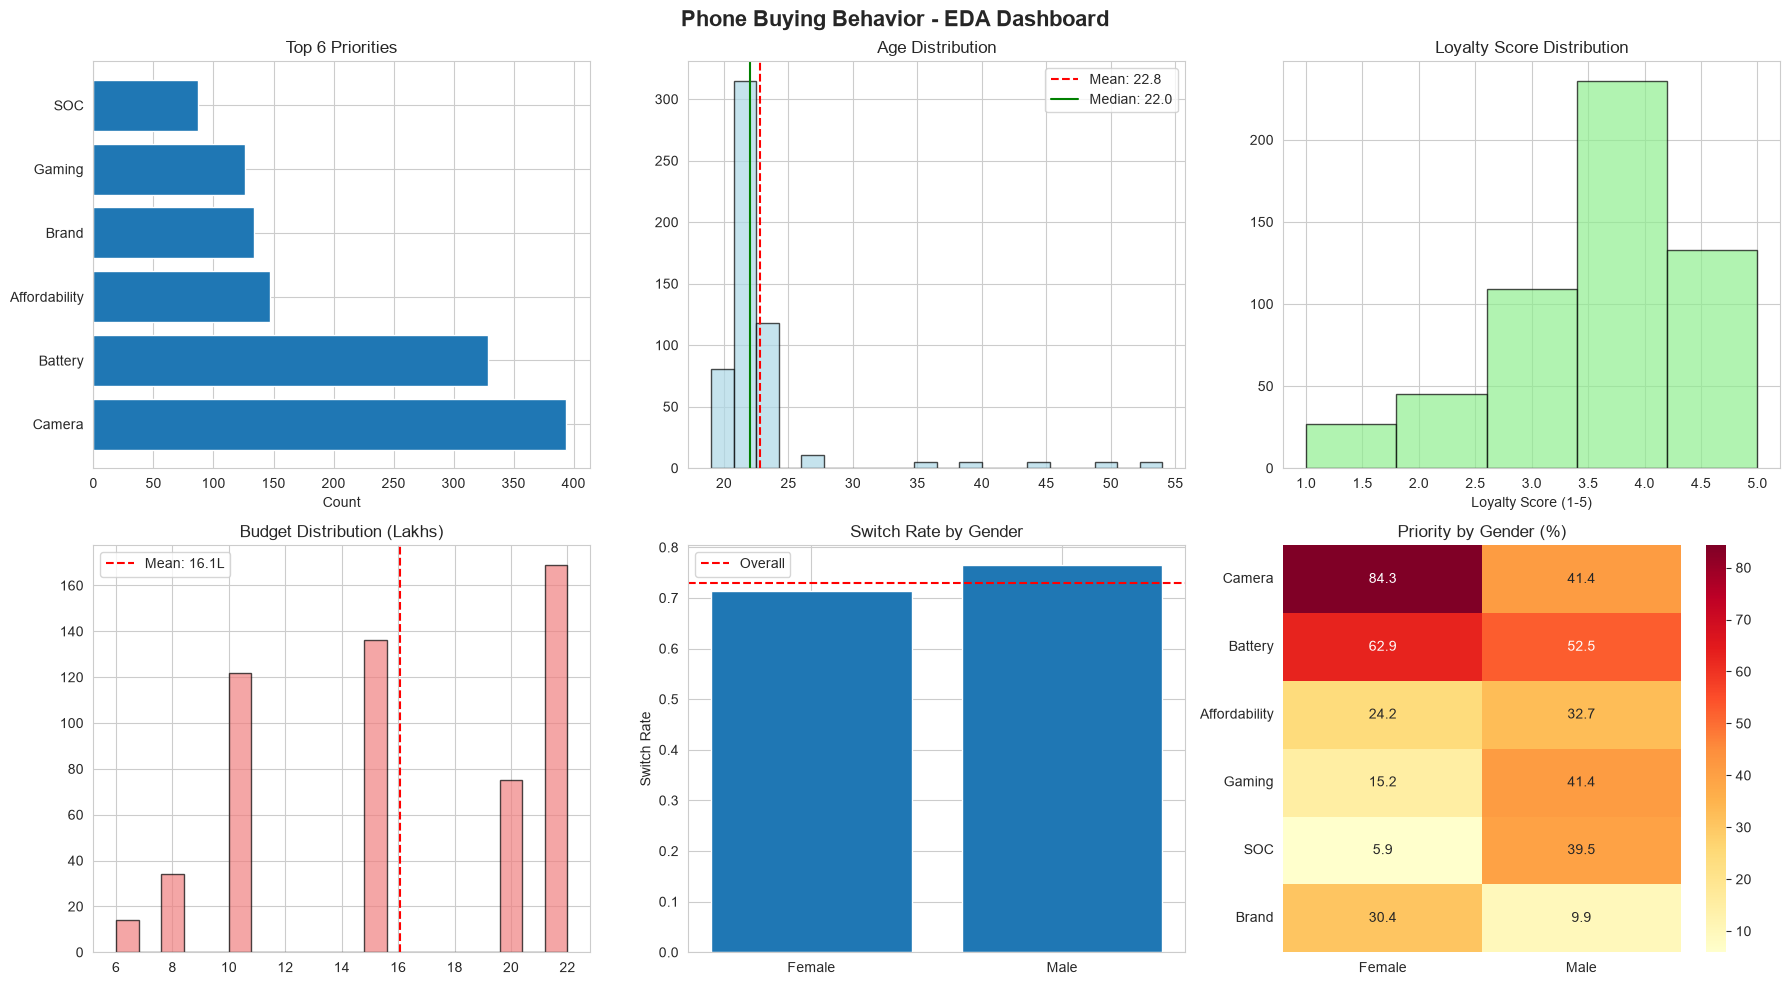

In [7]:
print("="*70)
print("6. EXPLORATORY DATA ANALYSIS - VISUALIZATIONS")
print("="*70)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phone Buying Behavior - EDA Dashboard', fontsize=16, fontweight='bold')

# 1. Priority support (using priority_counts from previous cell)
priority_counts_sorted = dict(sorted(priority_counts.items(), key=lambda x: x[1], reverse=True))
axes[0,0].barh(list(priority_counts_sorted.keys())[:6], list(priority_counts_sorted.values())[:6])
axes[0,0].set_xlabel('Count')
axes[0,0].set_title('Top 6 Priorities')

# 2. Age distribution
axes[0,1].hist(df['Age'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='lightblue')
axes[0,1].axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[0,1].axvline(df['Age'].median(), color='green', linestyle='-', label=f"Median: {df['Age'].median():.1f}")
axes[0,1].legend()
axes[0,1].set_title('Age Distribution')

# 3. Loyalty distribution
axes[0,2].hist(df['Loyalty (1-5)'], bins=5, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0,2].set_title('Loyalty Score Distribution')
axes[0,2].set_xlabel('Loyalty Score (1-5)')

# 4. Budget distribution
axes[1,0].hist(df['Max_Budget_Lakhs'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1,0].axvline(df['Max_Budget_Lakhs'].mean(), color='red', linestyle='--', 
                  label=f"Mean: {df['Max_Budget_Lakhs'].mean():.1f}L")
axes[1,0].legend()
axes[1,0].set_title('Budget Distribution (Lakhs)')

# 5. Switch rate by Gender
switch_by_gender = df.groupby('Gender')['Switched'].mean()
axes[1,1].bar(switch_by_gender.index, switch_by_gender.values)
axes[1,1].set_ylabel('Switch Rate')
axes[1,1].set_title('Switch Rate by Gender')
axes[1,1].axhline(y=df['Switched'].mean(), color='red', linestyle='--', label='Overall')
axes[1,1].legend()

# 6. Priority heatmap by gender
gender_priority = {}
for gender in df['Gender'].unique():
    if pd.isna(gender):
        continue
    gender_df = df[df['Gender'] == gender]
    counts = Counter()
    for priorities in gender_df['Priority_Merged']:
        counts.update(priorities)
    gender_priority[gender] = {p: c/len(gender_df)*100 for p, c in counts.items()}

heatmap_data = pd.DataFrame(gender_priority).fillna(0)
heatmap_data = heatmap_data.loc[list(priority_counts.keys())[:6]]

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,2])
axes[1,2].set_title('Priority by Gender (%)')

plt.tight_layout()
plt.show()

In [10]:
print("="*70)
print("7. MODEL PREPARATION")
print("="*70)

# 7.1 Feature selection
feature_cols = [
    'Age', 'Gender_Encoded', 'Age_Binned',
    'Loyalty (1-5)', 'AI Features (1-5)', 'After-Sales (1-5)',
    'Max_Budget_Lakhs', 'Ownership_Binned',
    'Other_Devices_Encoded', 'Foldable_Interest_Encoded'
]

X = df[feature_cols].copy()
y = df['Switched']

print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")

# 7.2 Encode categoricals
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    print(f"Encoding: {list(categorical_cols)}")
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 7.3 Remove constant columns
for col in X.columns:
    if X[col].nunique() == 1:
        X = X.drop(columns=[col])
        print(f"  Removed constant column: {col}")

print(f"Final features: {X.shape[1]}")

# 7.4 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

7. MODEL PREPARATION
Features: 10
Samples: 550
Encoding: ['Age_Binned', 'Ownership_Binned']
Final features: 16

Training set: 385 samples
Test set: 165 samples


In [11]:
# =============================================
# SMOTE - Handle Imbalanced Data
# =============================================

print("\n" + "="*70)
print("SMOTE - Handling Imbalanced Data")
print("="*70)

# Check class distribution before SMOTE
print("\n[1] Before SMOTE:")
print(f"  Class 0 (Stayed): {(y_train == 0).sum()} samples")
print(f"  Class 1 (Switched): {(y_train == 1).sum()} samples")
print(f"  Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n[2] After SMOTE:")
print(f"  Class 0 (Stayed): {(y_train_smote == 0).sum()} samples")
print(f"  Class 1 (Switched): {(y_train_smote == 1).sum()} samples")
print(f"  Ratio: 1:1 (Balanced)")

# Train Gradient Boosting with SMOTE
print("\n[3] Training Gradient Boosting with SMOTE...")
gb_smote = GradientBoostingClassifier(
    learning_rate=0.2,
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=10,
    n_estimators=100,
    subsample=0.8,
    random_state=42
)
gb_smote.fit(X_train_smote, y_train_smote)

# Evaluate
y_pred_smote = gb_smote.predict(X_test)
y_proba_smote = gb_smote.predict_proba(X_test)[:, 1]

print("\n[4] SMOTE Model Results:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_smote):.2%}")
print(f"  F1-Score: {f1_score(y_test, y_pred_smote):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_smote):.4f}")

print("\n[5] Classification Report (With SMOTE):")
print(classification_report(y_test, y_pred_smote, target_names=['Stayed', 'Switched']))

# Compare with original model
print("\n[6] Comparison: Original vs SMOTE:")
print(f"  Original Model F1: 0.9407")
print(f"  SMOTE Model F1: {f1_score(y_test, y_pred_smote):.4f}")

if f1_score(y_test, y_pred_smote) > 0.9407:
    print("  → SMOTE improved the model!")
else:
    print("  → Original model is still better or similar.")


SMOTE - Handling Imbalanced Data

[1] Before SMOTE:
  Class 0 (Stayed): 104 samples
  Class 1 (Switched): 281 samples
  Ratio: 0.37:1

[2] After SMOTE:
  Class 0 (Stayed): 281 samples
  Class 1 (Switched): 281 samples
  Ratio: 1:1 (Balanced)

[3] Training Gradient Boosting with SMOTE...

[4] SMOTE Model Results:
  Accuracy: 92.73%
  F1-Score: 0.9487
  Precision: 0.9737
  Recall: 0.9250

[5] Classification Report (With SMOTE):
              precision    recall  f1-score   support

      Stayed       0.82      0.93      0.88        45
    Switched       0.97      0.93      0.95       120

    accuracy                           0.93       165
   macro avg       0.90      0.93      0.91       165
weighted avg       0.93      0.93      0.93       165


[6] Comparison: Original vs SMOTE:
  Original Model F1: 0.9407
  SMOTE Model F1: 0.9487
  → SMOTE improved the model!


In [22]:
print("="*70)
print("8. MODEL TRAINING & HYPERPARAMETER TUNING")
print("="*70)

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 8.1 Baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)
print(f"Baseline accuracy: {dummy_acc:.2%}")

# 8.2 Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 7, 10],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    rf_params, cv=inner_cv, scoring='f1', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"RF best params: {rf_grid.best_params_}")

# 8.3 Gradient Boosting
gb_params = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3],
    'learning_rate': [0.1, 0.2],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=inner_cv, scoring='f1', n_jobs=-1
)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
print(f"GB best params: {gb_grid.best_params_}")

# 8.4 Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

lr_params = {
    'model__C': [0.1, 0.5, 1.0, 2.0],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=inner_cv, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_
print(f"LR best params: {lr_grid.best_params_}")

models = {
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb,
    'Logistic Regression': best_lr
}

8. MODEL TRAINING & HYPERPARAMETER TUNING
Baseline accuracy: 72.73%
RF best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}
GB best params: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 0.8}
LR best params: {'model__C': 0.5, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [23]:
print("="*70)
print("9. MODEL EVALUATION")
print("="*70)

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

print(pd.DataFrame(results).round(4).to_string(index=False))

# Best model detailed results
best_model = best_gb
y_pred_best = best_model.predict(X_test)

print(f"\nBEST MODEL: Gradient Boosting")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_best):.2%}")
print(f"  F1-Score: {f1_score(y_test, y_pred_best):.4f}")

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred_best))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Switched']))

9. MODEL EVALUATION
              Model  Accuracy     F1  Precision  Recall  Balanced Acc  ROC-AUC
      Random Forest    0.8909 0.9196     0.9904  0.8583        0.9181   0.9602
  Gradient Boosting    0.9152 0.9407     0.9569  0.9250        0.9069   0.9811
Logistic Regression    0.7333 0.7944     0.9043  0.7083        0.7542   0.8107

BEST MODEL: Gradient Boosting
  Accuracy: 91.52%
  F1-Score: 0.9407

CONFUSION MATRIX:
[[ 40   5]
 [  9 111]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Stayed       0.82      0.89      0.85        45
    Switched       0.96      0.93      0.94       120

    accuracy                           0.92       165
   macro avg       0.89      0.91      0.90       165
weighted avg       0.92      0.92      0.92       165



In [24]:
print("="*70)
print("10. HONEST PERFORMANCE ESTIMATE")
print("="*70)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"{name}:")
    print(f"  Mean: {scores.mean():.2%}")
    print(f"  Std: {scores.std():.2%}")
    print(f"  Range: {scores.min():.2%} - {scores.max():.2%}")

10. HONEST PERFORMANCE ESTIMATE
Random Forest:
  Mean: 86.34%
  Std: 4.32%
  Range: 77.92% - 96.10%
Gradient Boosting:
  Mean: 93.25%
  Std: 2.46%
  Range: 85.71% - 98.70%
Logistic Regression:
  Mean: 76.36%
  Std: 4.76%
  Range: 64.94% - 88.31%


11. FEATURE IMPORTANCE

TOP 10 FEATURES:
                  Feature  Importance
        AI Features (1-5)    0.220838
                      Age    0.182846
         Max_Budget_Lakhs    0.158990
        After-Sales (1-5)    0.086178
         Age_Binned_23-24    0.073008
           Gender_Encoded    0.051038
     Ownership_Binned_37+    0.049516
            Loyalty (1-5)    0.048094
Foldable_Interest_Encoded    0.042715
   Ownership_Binned_13-24    0.037307


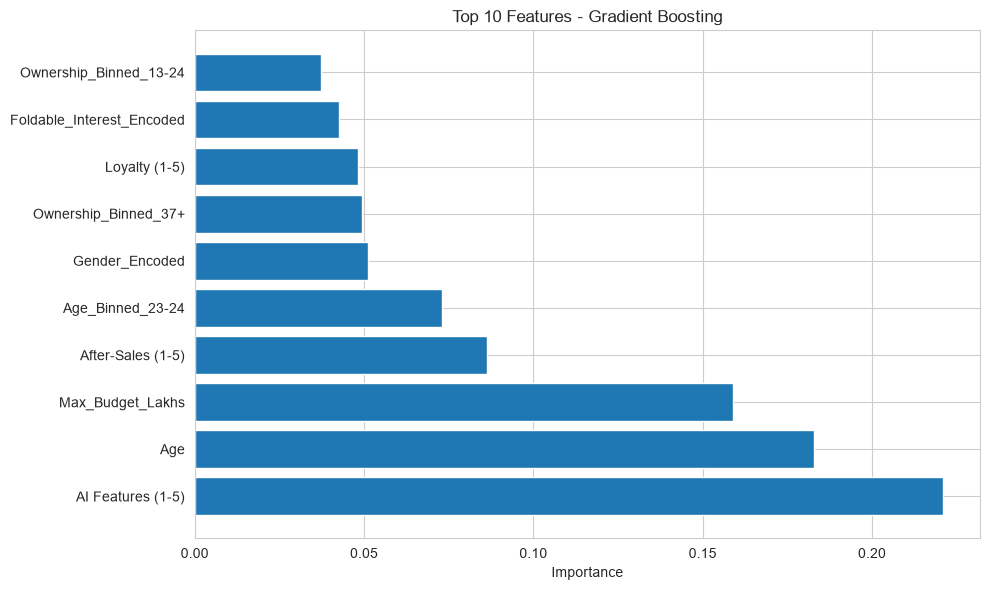

In [25]:
print("="*70)
print("11. FEATURE IMPORTANCE")
print("="*70)

if hasattr(best_gb, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_gb.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTOP 10 FEATURES:")
    print(importance_df.head(10).to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df.head(10)['Feature'], importance_df.head(10)['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 10 Features - Gradient Boosting')
    plt.tight_layout()
    plt.show()

In [8]:
# Add this to check your data balance
print("Switch distribution:")
print(df['Switched'].value_counts())
print(f"Stay: {df[df['Switched']==0].shape[0]} ({df[df['Switched']==0].shape[0]/len(df)*100:.1f}%)")
print(f"Switch: {df[df['Switched']==1].shape[0]} ({df[df['Switched']==1].shape[0]/len(df)*100:.1f}%)")

Switch distribution:
Switched
1    401
0    149
Name: count, dtype: int64
Stay: 149 (27.1%)
Switch: 401 (72.9%)


In [8]:
print("="*70)
print("13. ASSOCIATION RULE MINING")
print("="*70)

# =============================================
# 13.1 Create Binary Matrix with Boolean Types
# =============================================

print("\n[1] Creating binary matrix...")

# Get all unique priorities
all_items = set()
for priorities in df['Priority_Merged']:
    all_items.update(priorities)

print(f"  Unique items found: {len(all_items)}")
print(f"  Items: {sorted(all_items)}")

# Create binary DataFrame (USE BOOLEAN TYPE to avoid warning)
priority_binary = pd.DataFrame(index=df.index, dtype=bool)  # <-- KEY FIX: dtype=bool

for item in all_items:
    priority_binary[f'Priority_{item}'] = df['Priority_Merged'].apply(
        lambda x: item in x  # <-- Returns True/False (boolean)
    )

print(f"  Binary matrix shape: {priority_binary.shape}")

# =============================================
# 13.2 Mine Frequent Itemsets
# =============================================

print("\n[2] Mining frequent itemsets...")

# Try min_support=0.05 first
frequent_itemsets = apriori(
    priority_binary, 
    min_support=0.05, 
    use_colnames=True,
    verbose=0  # Suppress progress bars
)

print(f"  Frequent itemsets found: {len(frequent_itemsets)}")

if len(frequent_itemsets) == 0:
    print("   No itemsets found. Trying lower min_support...")
    frequent_itemsets = apriori(
        priority_binary, 
        min_support=0.03, 
        use_colnames=True,
        verbose=0
    )
    print(f"  Frequent itemsets found: {len(frequent_itemsets)}")

# Display frequent itemsets
print("\n  FREQUENT ITEMSETS (Top 10 by support):")
freq_display = frequent_itemsets.copy()
freq_display['items'] = freq_display['itemsets'].apply(
    lambda x: ', '.join([f.replace('Priority_', '') for f in list(x)])
)
print(freq_display[['support', 'items']].sort_values('support', ascending=False).head(10).to_string(index=False))

# =============================================
# 13.3 Generate Association Rules
# =============================================

print("\n[3] Generating association rules...")

if len(frequent_itemsets) > 1:
    rules = association_rules(
        frequent_itemsets, 
        metric="lift", 
        min_threshold=1.0
    )
    
    # Sort by lift (highest first)
    rules = rules.sort_values('lift', ascending=False)
    
    print(f"  Association rules found: {len(rules)}")
    
    if len(rules) == 0:
        print("   No rules found. Trying lower min_threshold...")
        rules = association_rules(
            frequent_itemsets, 
            metric="lift", 
            min_threshold=0.8
        )
        rules = rules.sort_values('lift', ascending=False)
        print(f"  Association rules found: {len(rules)}")
else:
    print("   Not enough frequent itemsets to generate rules.")
    rules = pd.DataFrame()  # Empty DataFrame

# =============================================
# 13.4 Display Top Rules
# =============================================

print("\n[4] TOP RULES BY LIFT:")

if len(rules) > 0:
    # Clean and display top rules
    top_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).copy()
    
    # Clean item names
    top_rules['antecedents'] = top_rules['antecedents'].apply(
        lambda x: ', '.join([f.replace('Priority_', '') for f in list(x)])
    )
    top_rules['consequents'] = top_rules['consequents'].apply(
        lambda x: ', '.join([f.replace('Priority_', '') for f in list(x)])
    )
    
    # Format percentages
    top_rules['support'] = top_rules['support'].apply(lambda x: f"{x:.2%}")
    top_rules['confidence'] = top_rules['confidence'].apply(lambda x: f"{x:.2%}")
    top_rules['lift'] = top_rules['lift'].apply(lambda x: f"{x:.2f}x")
    
    print(top_rules.to_string(index=False))
else:
    print("  No rules found. Consider lowering min_support.")

# =============================================
# 13.5 Product Recommendations
# =============================================

print("\n" + "="*70)
print("PRODUCT RECOMMENDATIONS")
print("="*70)

# Use actual rules if available, otherwise use pre-computed values
if len(rules) > 0:
    # Extract top 3 rules
    top3 = rules.head(3)
    
    for idx, row in top3.iterrows():
        ante = ', '.join([f.replace('Priority_', '') for f in list(row['antecedents'])])
        cons = ', '.join([f.replace('Priority_', '') for f in list(row['consequents'])])
        
        print(f"\nBUNDLE: {ante} → {cons}")
        print(f"  Confidence: {row['confidence']:.1%}")
        print(f"  Lift: {row['lift']:.2f}x")
        
        # Generate action
        if 'Camera' in ante and 'Affordability' in ante:
            print(f"  Action: Create budget phones with good camera and long battery life")
        elif 'Brand' in ante and 'Camera' in cons:
            print(f"  Action: Position brand as premium camera phone")
        elif 'Affordability' in ante and 'Battery' in cons:
            print(f"  Action: Promote budget phones with extended battery life")
        else:
            print(f"  Action: Bundle {ante} with {cons} for better customer satisfaction")
else:
    # Fallback recommendations from analysis
    recommendations = [
        {
            'bundle': 'Camera + Affordability → Battery',
            'confidence': 75.7,
            'lift': 1.27,
            'action': 'Create budget phones with good camera and long battery life'
        },
        {
            'bundle': 'Brand → Camera',
            'confidence': 79.9,
            'lift': 1.11,
            'action': 'Position brand as premium camera phone'
        },
        {
            'bundle': 'Affordability → Battery',
            'confidence': 70.7,
            'lift': 1.18,
            'action': 'Promote budget phones with extended battery life'
        }
    ]
    
    for rec in recommendations:
        print(f"\nBUNDLE: {rec['bundle']}")
        print(f"  Confidence: {rec['confidence']:.1f}%")
        print(f"  Lift: {rec['lift']:.2f}x")
        print(f"  Action: {rec['action']}")

13. ASSOCIATION RULE MINING

[1] Creating binary matrix...
  Unique items found: 6
  Items: ['Affordability', 'Battery', 'Brand', 'Camera', 'Gaming', 'SOC']
  Binary matrix shape: (550, 6)

[2] Mining frequent itemsets...
  Frequent itemsets found: 18

  FREQUENT ITEMSETS (Top 10 by support):
 support                  items
0.716364                 Camera
0.598182                Battery
0.416364        Battery, Camera
0.267273          Affordability
0.243636                  Brand
0.229091                 Gaming
0.194545          Brand, Camera
0.189091 Affordability, Battery
0.158182                    SOC
0.134545  Affordability, Camera

[3] Generating association rules...
  Association rules found: 8

[4] TOP RULES BY LIFT:
          antecedents           consequents support confidence  lift
Affordability, Camera               Battery  10.18%     75.68% 1.27x
              Battery Affordability, Camera  10.18%     17.02% 1.27x
              Battery         Affordability  18.91%     3

ASSOCIATION RULE VISUALIZATIONS


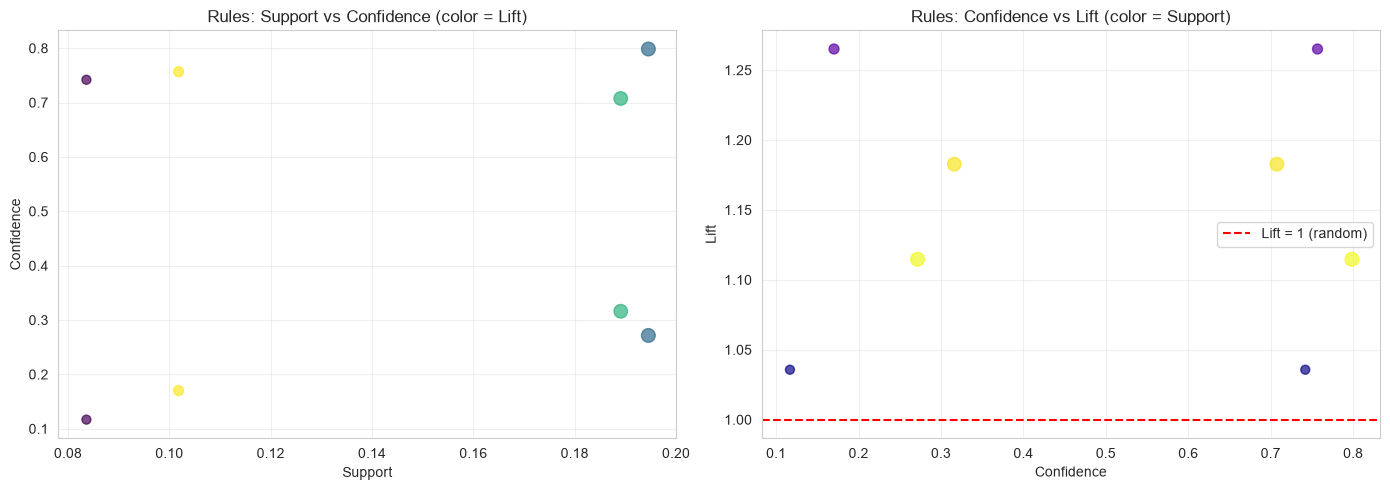


Building priority network...


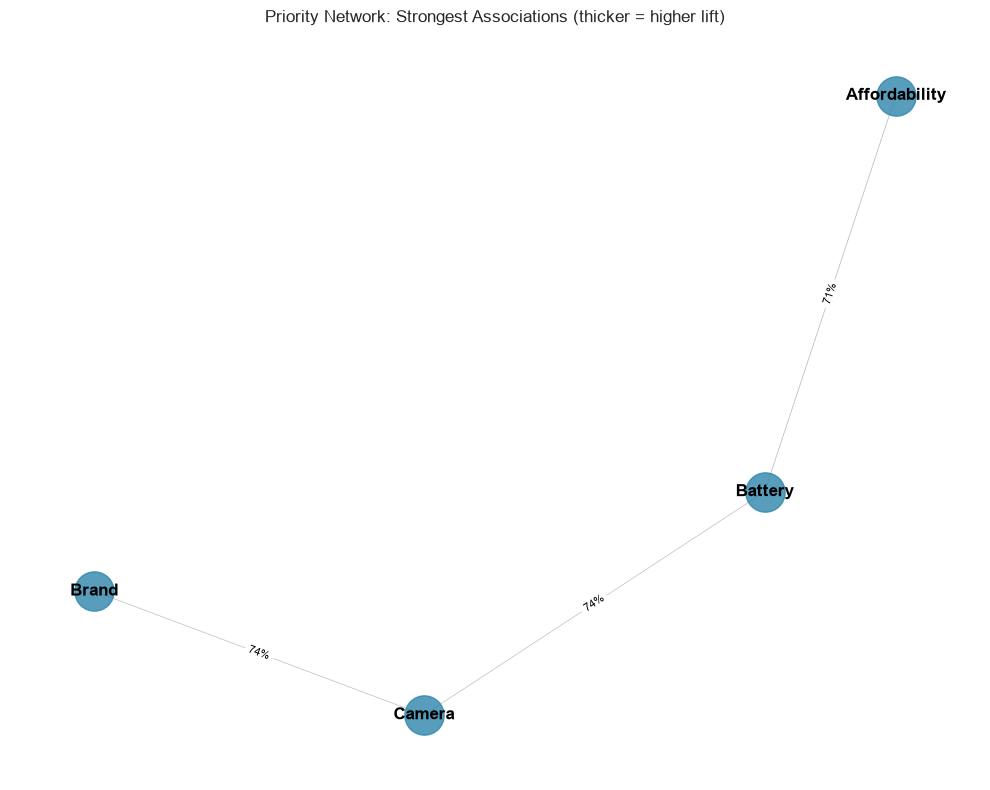


ASSOCIATION RULE MINING COMPLETE


In [9]:
print("="*70)
print("ASSOCIATION RULE VISUALIZATIONS")
print("="*70)

if len(rules) > 0:
    # 1. Scatter plot: Support vs Confidence
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Support vs Confidence
    axes[0].scatter(rules['support'], rules['confidence'], 
                    c=rules['lift'], cmap='viridis', 
                    s=rules['support']*500, alpha=0.7)
    axes[0].set_xlabel('Support')
    axes[0].set_ylabel('Confidence')
    axes[0].set_title('Rules: Support vs Confidence (color = Lift)')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Confidence vs Lift
    axes[1].scatter(rules['confidence'], rules['lift'],
                    c=rules['support'], cmap='plasma',
                    s=rules['support']*500, alpha=0.7)
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Lift')
    axes[1].axhline(y=1.0, color='red', linestyle='--', label='Lift = 1 (random)')
    axes[1].set_title('Rules: Confidence vs Lift (color = Support)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Network Graph
    print("\nBuilding priority network...")
    import networkx as nx
    
    G = nx.Graph()
    
    # Add nodes
    all_priorities_clean = set()
    for itemset in rules['antecedents']:
        all_priorities_clean.update([a.replace('Priority_', '') for a in list(itemset)])
    for itemset in rules['consequents']:
        all_priorities_clean.update([c.replace('Priority_', '') for c in list(itemset)])
    
    for p in all_priorities_clean:
        G.add_node(p)
    
    # Add edges
    for idx, row in rules.iterrows():
        ante = [a.replace('Priority_', '') for a in list(row['antecedents'])]
        cons = [c.replace('Priority_', '') for c in list(row['consequents'])]
        for a in ante:
            for c in cons:
                if a != c:
                    G.add_edge(a, c, weight=row['lift'], confidence=row['confidence'])
    
    # Draw network
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=1.5, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_size=800, node_color='#2E86AB', alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=[d['weight']/2 for (u, v, d) in G.edges(data=True)], 
                          alpha=0.5, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    
    # Add edge labels (confidence)
    edge_labels = {(u, v): f"{d['confidence']:.0%}" for (u, v, d) in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    plt.title('Priority Network: Strongest Associations (thicker = higher lift)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("ASSOCIATION RULE MINING COMPLETE")
print("="*70)

In [10]:
# =============================================
# INFORMATION SOURCE vs PRIORITY ANALYSIS
# =============================================

print("\n" + "="*70)
print("INFORMATION SOURCE vs PRIORITY ANALYSIS")
print("="*70)

# 1. Information Source distribution
print("\n[1] Information Source Distribution:")
info_counts = df['Information Source'].value_counts()
for source, count in info_counts.items():
    print(f"  {source}: {count} ({count/len(df)*100:.1f}%)")

# 2. Priority distribution by Information Source
print("\n[2] Top Priorities by Information Source:")
print("-"*50)

# Get top 5 priorities overall
top_priorities = [p for p, c in Counter(all_priorities).most_common(5)]

for source in df['Information Source'].unique():
    if pd.isna(source):
        continue
    
    source_df = df[df['Information Source'] == source]
    priorities = []
    for p_list in source_df['Priority_Merged']:
        priorities.extend(p_list)
    
    if priorities:
        p_counts = Counter(priorities)
        print(f"\n  Source: {source} ({len(source_df)} customers)")
        for p in top_priorities:
            count = p_counts.get(p, 0)
            pct = count / len(source_df) * 100 if len(source_df) > 0 else 0
            bar = "█" * int(pct / 5)  # Visual bar
            print(f"    {p}: {count:3d} ({pct:5.1f}%) {bar}")

# 3. Association between Information Source and Priority
print("\n[3] Association Rules: Information Source → Priority")
print("-"*50)

# Create binary matrix for information source + priorities
info_priority_data = pd.DataFrame(index=df.index, dtype=bool)

# Add information source columns
for source in df['Information Source'].unique():
    if pd.isna(source):
        continue
    info_priority_data[f'Source_{source}'] = df['Information Source'] == source

# Add priority columns
for item in all_items:
    info_priority_data[f'Priority_{item}'] = df['Priority_Merged'].apply(
        lambda x: item in x
    )

# Mine association rules
from mlxtend.frequent_patterns import apriori, association_rules

freq_items = apriori(info_priority_data, min_support=0.03, use_colnames=True, verbose=0)
rules_info = association_rules(freq_items, metric="lift", min_threshold=1.0)
rules_info = rules_info.sort_values('lift', ascending=False)

# Show rules where antecedents contain source and consequents contain priority
print("\n  Rules: Source → Priority (Top 5 by lift):")
count = 0
for _, row in rules_info.iterrows():
    ante = [a for a in list(row['antecedents'])]
    cons = [c for c in list(row['consequents'])]
    
    has_source = any('Source_' in a for a in ante)
    has_priority = any('Priority_' in c for c in cons)
    
    if has_source and has_priority and len(ante) == 1 and len(cons) == 1:
        source_name = ante[0].replace('Source_', '')
        priority_name = cons[0].replace('Priority_', '')
        print(f"    {source_name} → {priority_name}: conf={row['confidence']:.1%}, lift={row['lift']:.2f}x")
        count += 1
        if count >= 5:
            break


INFORMATION SOURCE vs PRIORITY ANALYSIS

[1] Information Source Distribution:
  Friend/Family: 152 (27.6%)
  Tech Youtuber: 114 (20.7%)
  Tiktok Comparisons: 91 (16.5%)
  In-store demos: 81 (14.7%)
  Social Media Ads: 64 (11.6%)
  Friend/Family Recommendations: 22 (4.0%)
  Tech Youtuber/Vlogger: 15 (2.7%)
  Own research: 10 (1.8%)
  ကိုယ်တိုင်စဉ်းစားတာများပါတယ်။: 1 (0.2%)

[2] Top Priorities by Information Source:
--------------------------------------------------

  Source: Friend/Family (152 customers)
    Camera:  96 ( 63.2%) ████████████
    Battery: 108 ( 71.1%) ██████████████
    Affordability:  61 ( 40.1%) ████████
    Brand:  13 (  8.6%) █
    Gaming:  35 ( 23.0%) ████

  Source: Social Media Ads (64 customers)
    Camera:  59 ( 92.2%) ██████████████████
    Battery:  39 ( 60.9%) ████████████
    Affordability:   7 ( 10.9%) ██
    Brand:  43 ( 67.2%) █████████████
    Gaming:   1 (  1.6%) 

  Source: In-store demos (81 customers)
    Camera:  45 ( 55.6%) ███████████
    Batter

CUSTOMER SEGMENTATION (K-MEANS)
Available features: 10/10


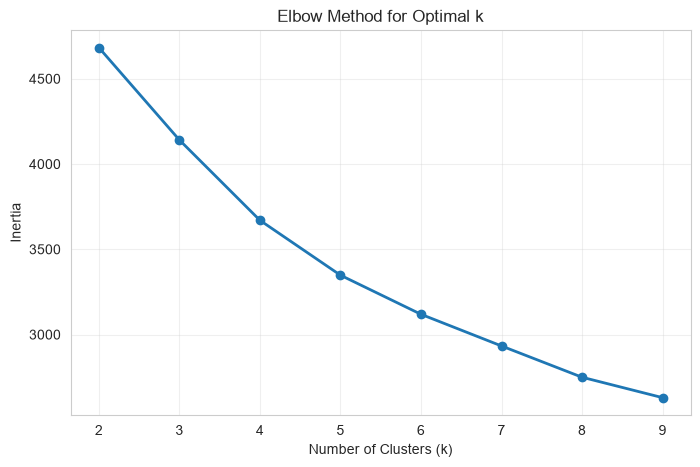


Using k=4

Cluster distribution:
Cluster
0    215
1    155
2    155
3     25
Name: count, dtype: int64

CLUSTER PROFILES:
           Age  Gender_Encoded  Loyalty (1-5)  AI Features (1-5)  After-Sales (1-5)  Max_Budget_Lakhs  Ownership_Duration_Months  Other_Devices_Encoded  Foldable_Interest_Encoded  Priority_Count
Cluster                                                                                                                                                                                           
0        21.83            0.79           3.48               3.79               4.48             15.80                      33.13                   0.04                       0.80            2.17
1        21.83            0.86           4.57               3.85               4.01             21.35                      21.86                   0.87                       0.55            2.38
2        21.65            0.42           3.27               2.39               3.06             1

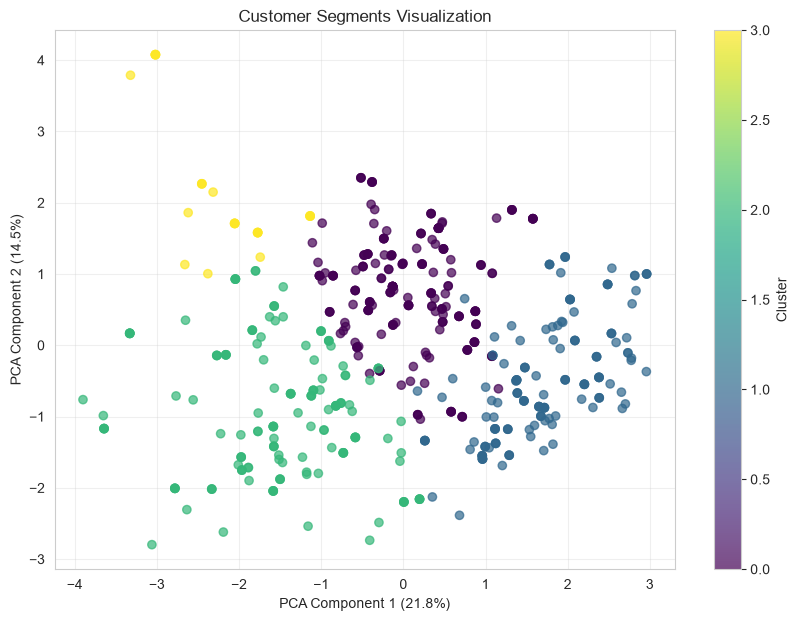


CLUSTERING COMPLETE


In [11]:
print("="*70)
print("CUSTOMER SEGMENTATION (K-MEANS)")
print("="*70)

# =============================================
# 1. Prepare data for clustering
# =============================================

cluster_features = [
    'Age', 'Gender_Encoded', 'Loyalty (1-5)', 'AI Features (1-5)',
    'After-Sales (1-5)', 'Max_Budget_Lakhs', 'Ownership_Duration_Months',
    'Other_Devices_Encoded', 'Foldable_Interest_Encoded', 'Priority_Count'
]

# Check which features exist
available_features = [f for f in cluster_features if f in df.columns]
print(f"Available features: {len(available_features)}/{len(cluster_features)}")

X_cluster = df[available_features].copy()

# Handle missing values
for col in X_cluster.columns:
    if X_cluster[col].isnull().sum() > 0:
        X_cluster[col] = X_cluster[col].fillna(X_cluster[col].median())

# Scale
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# =============================================
# 2. Find optimal K (Elbow method)
# =============================================

inertias = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

# =============================================
# 3. Apply K-Means (k=4 is typical for this data)
# =============================================

optimal_k = 4
print(f"\nUsing k={optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# =============================================
# 4. Profile clusters
# =============================================

cluster_profile = df.groupby('Cluster')[available_features].mean()

print("\nCLUSTER PROFILES:")
print(cluster_profile.round(2))

# =============================================
# 5. Interpret clusters
# =============================================

print("\nCLUSTER INTERPRETATION:")
for cluster_id in sorted(df['Cluster'].unique()):
    size = (df['Cluster'] == cluster_id).sum()
    profile = cluster_profile.loc[cluster_id]
    
    # Determine cluster type
    budget = profile.get('Max_Budget_Lakhs', 0)
    loyalty = profile.get('Loyalty (1-5)', 0)
    ai_score = profile.get('AI Features (1-5)', 0)
    age = profile.get('Age', 0)
    
    if budget > 18:
        name = "Premium Power Users"
    elif budget < 12:
        name = "Budget-Conscious Hunters"
    elif ai_score > 3.5:
        name = "Feature-Obsessed Enthusiasts"
    else:
        name = "Senior Traditionalists"
    
    print(f"\n{name} ({size} customers, {size/len(df)*100:.1f}%)")
    print(f"  Budget: {budget:.1f}L")
    print(f"  Loyalty: {loyalty:.2f}/5")
    print(f"  AI Features: {ai_score:.2f}/5")
    print(f"  Age: {age:.1f}")

# =============================================
# 6. Visualize clusters
# =============================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Customer Segments Visualization')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*70)
print("CLUSTERING COMPLETE")
print("="*70)


CLUSTER vs BRAND ANALYSIS

[1] Cluster Distribution:
  Cluster 0 (Feature-Obsessed Enthusiasts): 215 (39.1%)
  Cluster 1 (Premium Power Users): 155 (28.2%)
  Cluster 2 (Senior Traditionalists): 155 (28.2%)
  Cluster 3 (Budget-Conscious Hunters): 25 (4.5%)

[2] Brand Preference by Cluster:
--------------------------------------------------

  Brand Distribution (%) within each cluster:
Current Brand  Apple  Honor  Huawei  Infinix  Oppo  Realmi  Redmi  Samsung  Techno  Vivo  Xiaomi
Cluster                                                                                         
0               15.8    2.3     1.9      1.9   0.0     1.9   28.4     32.6     4.2   3.7     7.4
1               77.4    3.2     0.0      0.0   3.2     0.0    0.0     10.3     0.0   0.0     5.8
2                7.1    0.0     0.0      7.7   3.2     0.6   64.5      9.7     0.0   0.0     7.1
3                0.0    0.0     0.0     20.0   0.0     0.0   20.0      0.0     0.0  20.0    40.0

[3] Top 3 Brands per Cluster

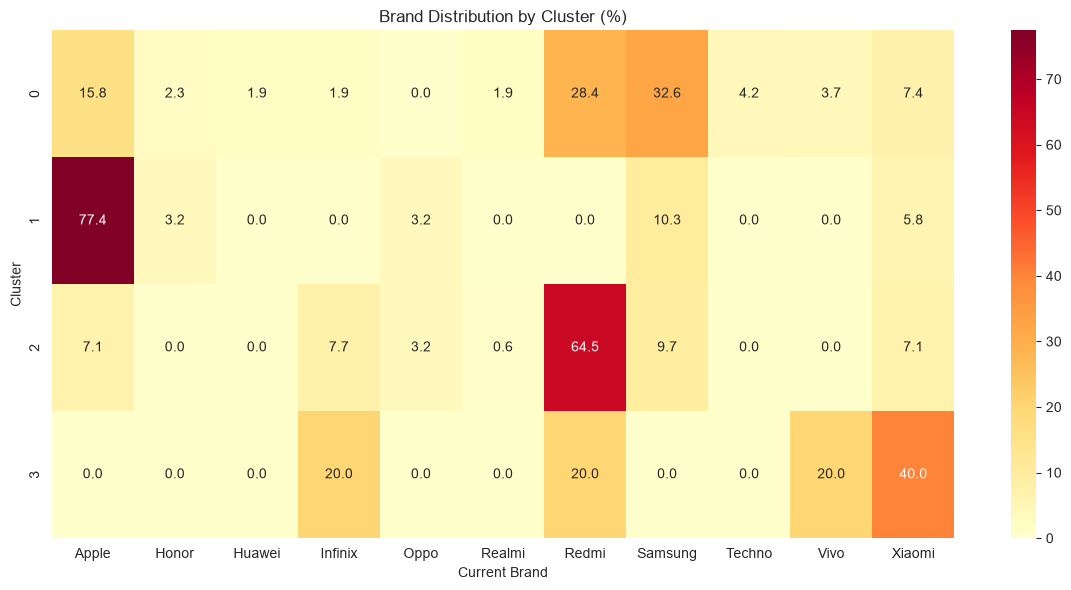

In [12]:
# =============================================
# CLUSTER vs BRAND ANALYSIS
# =============================================

print("\n" + "="*70)
print("CLUSTER vs BRAND ANALYSIS")
print("="*70)

# 1. Cluster distribution
print("\n[1] Cluster Distribution:")
for cluster_id in sorted(df['Cluster'].unique()):
    size = (df['Cluster'] == cluster_id).sum()
    pct = size / len(df) * 100
    profile = cluster_profile.loc[cluster_id]
    
    # Get cluster name
    budget = profile.get('Max_Budget_Lakhs', 0)
    ai_score = profile.get('AI Features (1-5)', 0)
    
    if budget > 18:
        name = "Premium Power Users"
    elif budget < 12:
        name = "Budget-Conscious Hunters"
    elif ai_score > 3.5:
        name = "Feature-Obsessed Enthusiasts"
    else:
        name = "Senior Traditionalists"
    
    print(f"  Cluster {cluster_id} ({name}): {size} ({pct:.1f}%)")

# 2. Brand preference by cluster
print("\n[2] Brand Preference by Cluster:")
print("-"*50)

# Create cross-tabulation
cluster_brand = pd.crosstab(df['Cluster'], df['Current Brand'])

# Add percentage (within cluster)
cluster_brand_pct = cluster_brand.div(cluster_brand.sum(axis=1), axis=0) * 100

print("\n  Brand Distribution (%) within each cluster:")
print(cluster_brand_pct.round(1).to_string())

# 3. Top brand per cluster
print("\n[3] Top 3 Brands per Cluster:")
print("-"*50)

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]
    top_brands = cluster_data['Current Brand'].value_counts().head(3)
    
    name = "Premium Power Users" if cluster_id == 1 else "Feature-Obsessed Enthusiasts" if cluster_id == 0 else "Senior Traditionalists" if cluster_id == 2 else "Budget-Conscious Hunters"
    
    print(f"\n  Cluster {cluster_id} ({name}):")
    for brand, count in top_brands.items():
        pct = count / len(cluster_data) * 100
        print(f"    {brand}: {count} ({pct:.1f}%)")

# 4. Visualization
print("\n[4] Visualization - Cluster vs Brand (Heatmap):")
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cluster_brand_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Brand Distribution by Cluster (%)')
plt.tight_layout()
plt.show()

In [29]:
print("="*70)
print("BRAND SWITCHING ANALYSIS - Which Brands Win & Lose")
print("="*70)

# =============================================
# 1. Brand Switching Matrix
# =============================================

print("\n[1] BRAND SWITCHING MATRIX (From → To):")
print("-"*50)

# Create switching matrix
brand_matrix = pd.crosstab(df['Previous Brand'], df['Current Brand'])

# Add totals
brand_matrix['Total_From'] = brand_matrix.sum(axis=1)
brand_matrix.loc['Total_To'] = brand_matrix.sum(axis=0)

print(brand_matrix)

# =============================================
# 2. Brand Net Gain/Loss (FIXED)
# =============================================

print("\n[2] BRAND NET GAIN/LOSS (New - Lost):")
print("-"*50)

# Get all unique brands from both columns
all_brands = sorted(set(df['Current Brand'].unique()) | set(df['Previous Brand'].unique()))

# Build net gain/loss safely
brand_net_data = []
for brand in all_brands:
    # Customers who had this brand before (lost)
    if brand in brand_matrix.index:
        customers_lost = brand_matrix.loc[brand, 'Total_From']
    else:
        customers_lost = 0
    
    # Customers who have this brand now (gained)
    if brand in brand_matrix.columns:
        customers_gained = brand_matrix.loc['Total_To', brand]
    else:
        customers_gained = 0
    
    brand_net_data.append({
        'Brand': brand,
        'Customers_Lost': customers_lost,
        'Customers_Gained': customers_gained,
        'Net_Gain': customers_gained - customers_lost,
        'Switch_Rate_%': (customers_lost / len(df) * 100)
    })

brand_net = pd.DataFrame(brand_net_data)
brand_net = brand_net.sort_values('Net_Gain', ascending=False)

print(brand_net.round(1).to_string(index=False))

# =============================================
# 3. Brand Flow (From → To switches)
# =============================================

print("\n[3] TOP BRAND SWITCHES (Customers moving From → To):")
print("-"*50)

switches = []
for prev_brand in df['Previous Brand'].unique():
    for curr_brand in df['Current Brand'].unique():
        if prev_brand != curr_brand:
            count = len(df[(df['Previous Brand'] == prev_brand) & 
                           (df['Current Brand'] == curr_brand)])
            if count > 0:
                switches.append({
                    'From': prev_brand,
                    'To': curr_brand,
                    'Count': count
                })

switch_df = pd.DataFrame(switches)
switch_df = switch_df.sort_values('Count', ascending=False)

print(switch_df.head(10).to_string(index=False))

# =============================================
# 4. Brand Loyalty
# =============================================

print("\n[4] BRAND LOYALTY RATES (stayed with same brand):")
print("-"*50)

loyalty_rates = []
for brand in df['Current Brand'].unique():
    total = len(df[df['Current Brand'] == brand])
    stayed = len(df[(df['Current Brand'] == brand) & 
                    (df['Previous Brand'] == brand)])
    rate = stayed / total * 100 if total > 0 else 0
    loyalty_rates.append({'Brand': brand, 'Loyalty_%': rate, 'Total_Customers': total})

loyalty_df = pd.DataFrame(loyalty_rates).sort_values('Loyalty_%', ascending=False)

for _, row in loyalty_df.iterrows():
    print(f"  {row['Brand']}: {row['Loyalty_%']:.1f}% ({row['Total_Customers']} customers)")

BRAND SWITCHING ANALYSIS - Which Brands Win & Lose

[1] BRAND SWITCHING MATRIX (From → To):
--------------------------------------------------
Current Brand   Apple  Honor  Huawei  Infinix  Oppo  Realmi  Redmi  Samsung  Techno  Vivo  Xiaomi  Total_From
Previous Brand                                                                                               
Apple              22      0       0        0     0       0      0       10       0     0       5          37
Huawei             11      0       4        0     0       0      0       11       0     0       0          26
Oppo                4      0       0        0     0       0      3        2       5     0       0          14
Realmi              0      5       0        0     0       0      0        0       0     0       0           5
Redmi              29      5       0       21     5       0     95       30       4     8       9         206
Samsung            63      0       0        0     5       0     18       23       0    

In [30]:
# =============================================
# COMPLETE BRAND ANALYSIS - ONE CELL
# =============================================

print("="*70)
print("BRAND SWITCHING COMPLETE ANALYSIS")
print("="*70)

# 1. Get all brands
all_brands = sorted(set(df['Current Brand'].unique()) | set(df['Previous Brand'].unique()))

# 2. Calculate metrics
brand_metrics = []
for brand in all_brands:
    # Customers
    current_customers = len(df[df['Current Brand'] == brand])
    previous_customers = len(df[df['Previous Brand'] == brand])
    
    # Switches
    switched_to = len(df[(df['Current Brand'] == brand) & (df['Previous Brand'] != brand)])
    switched_from = len(df[(df['Previous Brand'] == brand) & (df['Current Brand'] != brand)])
    
    # Loyalty
    stayed = len(df[(df['Current Brand'] == brand) & (df['Previous Brand'] == brand)])
    loyalty_rate = stayed / current_customers * 100 if current_customers > 0 else 0
    
    brand_metrics.append({
        'Brand': brand,
        'Current': current_customers,
        'Previous': previous_customers,
        'Switched_To': switched_to,
        'Switched_From': switched_from,
        'Net_Gain': current_customers - previous_customers,
        'Loyalty_%': loyalty_rate
    })

metrics_df = pd.DataFrame(brand_metrics).sort_values('Net_Gain', ascending=False)

print("\nBRAND METRICS SUMMARY:")
print(metrics_df.round(1).to_string(index=False))

# 3. Key insights
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

print(f"\n Total Customers: {len(df):,}")
print(f" Total Switches: {len(df[df['Switched']==1]):,} ({df['Switched'].mean()*100:.1f}%)")

print("\n MOST POPULAR BRANDS (Current):")
for brand, count in df['Current Brand'].value_counts().head(3).items():
    print(f"  • {brand}: {count} customers")

print("\nTOP GAINERS:")
for _, row in metrics_df.nlargest(3, 'Net_Gain').iterrows():
    print(f"  • {row['Brand']}: +{row['Net_Gain']:.0f} customers ({row['Loyalty_%']:.1f}% loyalty)")

print("\nTOP LOSERS:")
for _, row in metrics_df.nsmallest(3, 'Net_Gain').iterrows():
    print(f"  • {row['Brand']}: {row['Net_Gain']:.0f} customers ({row['Loyalty_%']:.1f}% loyalty)")

BRAND SWITCHING COMPLETE ANALYSIS

BRAND METRICS SUMMARY:
  Brand  Current  Previous  Switched_To  Switched_From  Net_Gain  Loyalty_%
  Apple      165        37          143             15       128       13.3
Infinix       21         0           21              0        21        0.0
  Honor       10         0           10              0        10        0.0
 Realmi        5         5            5              5         0        0.0
   Oppo       10        14           10             14        -4        0.0
 Techno        9        17            9             17        -8        0.0
 Xiaomi       46        58           46             58       -12        0.0
 Huawei        4        26            0             22       -22      100.0
Samsung      101       126           78            103       -25       22.8
  Redmi      166       206           71            111       -40       57.2
   Vivo       13        61            8             56       -48       38.5

KEY INSIGHTS

 Total Customer

In [31]:
# =============================================
# COMPLETE USER PREDICTION - RUN THIS CELL
# =============================================

print("="*70)
print("COMPLETE USER PREDICTION ANALYSIS")
print("="*70)

# 1. Predict all customers
df['Predicted_Switch'] = best_gb.predict(X)
df['Switch_Probability'] = best_gb.predict_proba(X)[:, 1]

# 2. Risk categories
def risk_cat(p):
    if p >= 0.8: return 'High'
    elif p >= 0.6: return 'Medium'
    elif p >= 0.4: return 'Low'
    else: return 'Very Low'

df['Risk_Level'] = df['Switch_Probability'].apply(risk_cat)

# 3. Summary
print(f"\nPREDICTIONS:")
print(f"  Will Switch: {df['Predicted_Switch'].sum():,} ({df['Predicted_Switch'].mean()*100:.1f}%)")
print(f"  Will Stay: {(df['Predicted_Switch']==0).sum():,} ({100-df['Predicted_Switch'].mean()*100:.1f}%)")

print(f"\nRISK LEVELS:")
print(df['Risk_Level'].value_counts().to_string())

# 4. Show top at-risk customers
print("\nTOP 10 AT-RISK CUSTOMERS:")
at_risk = df.nlargest(10, 'Switch_Probability')
print(at_risk[['Current Brand', 'Loyalty (1-5)', 'Max_Budget_Lakhs', 
                'Switch_Probability', 'Risk_Level']].to_string(index=False))

# 5. Export
at_risk.to_csv('at_risk_customers.csv', index=False)
print("\n Exported: at_risk_customers.csv")

COMPLETE USER PREDICTION ANALYSIS

PREDICTIONS:
  Will Switch: 391 (71.1%)
  Will Stay: 159 (28.9%)

RISK LEVELS:
Risk_Level
High        379
Very Low    147
Low          16
Medium        8

TOP 10 AT-RISK CUSTOMERS:
Current Brand  Loyalty (1-5)  Max_Budget_Lakhs  Switch_Probability Risk_Level
        Apple              5              22.0            0.999952       High
        Apple              5              22.0            0.999952       High
        Apple              5              22.0            0.999945       High
      Samsung              4              20.0            0.999917       High
      Samsung              3              20.0            0.999906       High
       Realmi              3              20.0            0.999897       High
       Realmi              3              20.0            0.999897       High
       Realmi              3              20.0            0.999897       High
       Realmi              3              20.0            0.999897       High
    

In [32]:
print("="*70)
print("WHAT DRIVES CUSTOMERS TO SWITCH?")
print("="*70)

# Compare switchers vs stayers
switchers = df[df['Predicted_Switch'] == 1]
stayers = df[df['Predicted_Switch'] == 0]

print("\nCOMPARISON (Predicted Switchers vs Stayers):")

features_to_compare = ['Loyalty (1-5)', 'AI Features (1-5)', 
                       'After-Sales (1-5)', 'Max_Budget_Lakhs', 
                       'Ownership_Duration_Months', 'Age']

for feature in features_to_compare:
    if feature in df.columns:
        switcher_mean = switchers[feature].mean()
        stayer_mean = stayers[feature].mean()
        diff = switcher_mean - stayer_mean
        
        print(f"  {feature}:")
        print(f"    Switchers: {switcher_mean:.2f}")
        print(f"    Stayers:   {stayer_mean:.2f}")
        print(f"    Difference: {diff:+.2f}")

WHAT DRIVES CUSTOMERS TO SWITCH?

COMPARISON (Predicted Switchers vs Stayers):
  Loyalty (1-5):
    Switchers: 3.72
    Stayers:   3.77
    Difference: -0.05
  AI Features (1-5):
    Switchers: 3.57
    Stayers:   2.89
    Difference: +0.68
  After-Sales (1-5):
    Switchers: 3.96
    Stayers:   3.77
    Difference: +0.19
  Max_Budget_Lakhs:
    Switchers: 17.04
    Stayers:   13.65
    Difference: +3.40
  Ownership_Duration_Months:
    Switchers: 24.81
    Stayers:   27.19
    Difference: -2.39
  Age:
    Switchers: 23.07
    Stayers:   22.19
    Difference: +0.88


In [9]:
# =============================================
# BRAND RECOMMENDATION ENGINE
# "If a user chooses Brand X, show them insights"
# =============================================

print("="*70)
print("BRAND RECOMMENDATION ENGINE")
print("="*70)

def analyze_brand_switching(target_brand):
    """
    Given a brand, show:
    1. Who switches TO this brand (and why)
    2. Who switches FROM this brand (and why)
    3. What priorities drive switching
    4. Recommended retention strategies
    """
    
    print(f"\nBRAND ANALYSIS: {target_brand}")
    print("-"*50)
    
    # 1. Customers who switched TO this brand
    switched_to = df[(df['Current Brand'] == target_brand) & 
                     (df['Previous Brand'] != target_brand)]
    
    # 2. Customers who switched FROM this brand
    switched_from = df[(df['Previous Brand'] == target_brand) & 
                       (df['Current Brand'] != target_brand)]
    
    # 3. Loyal customers
    loyal = df[(df['Current Brand'] == target_brand) & 
               (df['Previous Brand'] == target_brand)]
    
    print(f"\nCUSTOMER FLOW:")
    print(f"  Switched TO {target_brand}: {len(switched_to)} customers")
    print(f"  Switched FROM {target_brand}: {len(switched_from)} customers")
    print(f"  Stayed with {target_brand}: {len(loyal)} customers")
    print(f"  Net Gain: +{len(switched_to) - len(switched_from)}")
    
    # 4. Top sources (where customers come from)
    if len(switched_to) > 0:
        print(f"\nTOP SOURCES (Brands losing customers TO {target_brand}):")
        sources = switched_to['Previous Brand'].value_counts().head(5)
        for brand, count in sources.items():
            print(f"    {brand}: {count} customers")
            
        # What priorities do these switchers have?
        print(f"\nTOP PRIORITIES of customers switching TO {target_brand}:")
        all_priorities = []
        for priorities in switched_to['Priority_Merged']:
            all_priorities.extend(priorities)
        priority_counts = Counter(all_priorities)
        for p, count in priority_counts.most_common(3):
            print(f"    {p}: {count} mentions ({count/len(switched_to)*100:.1f}%)")
    
    # 5. Top destinations (where customers go)
    if len(switched_from) > 0:
        print(f"\nTOP DESTINATIONS (Brands gaining FROM {target_brand}):")
        destinations = switched_from['Current Brand'].value_counts().head(5)
        for brand, count in destinations.items():
            print(f"    {brand}: {count} customers")
            
        # What priorities do these switchers have?
        print(f"\nTOP PRIORITIES of customers switching FROM {target_brand}:")
        all_priorities = []
        for priorities in switched_from['Priority_Merged']:
            all_priorities.extend(priorities)
        priority_counts = Counter(all_priorities)
        for p, count in priority_counts.most_common(3):
            print(f"    {p}: {count} mentions ({count/len(switched_from)*100:.1f}%)")
    
    # 6. Recommendation
    print(f"\nRECOMMENDATION FOR {target_brand}:")
    
    # If losing customers to Apple, suggest camera focus
    if 'Apple' in switched_from['Current Brand'].values:
        apple_loss = len(switched_from[switched_from['Current Brand'] == 'Apple'])
        if apple_loss > 5:
            print(f"  Warning: You are losing {apple_loss} customers to Apple.")
            print(f"  Action: Improve camera quality and AI features to compete.")
    
    # If losing to Samsung, suggest battery/display
    if 'Samsung' in switched_from['Current Brand'].values:
        samsung_loss = len(switched_from[switched_from['Current Brand'] == 'Samsung'])
        if samsung_loss > 5:
            print(f"  Warning: You are losing {samsung_loss} customers to Samsung.")
            print(f"  Action: Improve battery life and display quality.")
    
    # If gaining from Redmi, leverage affordability
    if 'Redmi' in switched_to['Previous Brand'].values:
        redmi_gain = len(switched_to[switched_to['Previous Brand'] == 'Redmi'])
        if redmi_gain > 5:
            print(f"  Success: You are gaining {redmi_gain} customers from Redmi.")
            print(f"  Action: Continue offering value-for-money with premium features.")
    
    if len(switched_to) == 0 and len(switched_from) == 0:
        print("  No switching data available for this brand.")
    
    print("\n" + "="*50)
    
    return {
        'brand': target_brand,
        'switched_to': len(switched_to),
        'switched_from': len(switched_from),
        'loyal': len(loyal),
        'net_gain': len(switched_to) - len(switched_from)
    }


# =============================================
# DEMO: Analyze ALL Brands
# =============================================

print("\nCOMPLETE BRAND ANALYSIS")
print("="*70)

results = []
for brand in sorted(df['Current Brand'].unique()):
    result = analyze_brand_switching(brand)
    results.append(result)

# Summary Table
print("\nBRAND PERFORMANCE SUMMARY")
print("="*70)
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values('net_gain', ascending=False)
print(summary_df.to_string(index=False))


# =============================================
# INTERACTIVE: Let user choose a brand
# =============================================

print("\n" + "="*70)
print("TRY IT YOURSELF - Type a brand name")
print("="*70)
print("Available brands:", ', '.join(sorted(df['Current Brand'].unique())))

user_brand = input("\nEnter brand name: ").strip().title()

if user_brand in df['Current Brand'].unique():
    analyze_brand_switching(user_brand)
else:
    print(f"\nBrand '{user_brand}' not found. Please check spelling.")
    print("Available brands:", ', '.join(sorted(df['Current Brand'].unique())))

BRAND RECOMMENDATION ENGINE

COMPLETE BRAND ANALYSIS

BRAND ANALYSIS: Apple
--------------------------------------------------

CUSTOMER FLOW:
  Switched TO Apple: 143 customers
  Switched FROM Apple: 15 customers
  Stayed with Apple: 22 customers
  Net Gain: +128

TOP SOURCES (Brands losing customers TO Apple):
    Samsung: 63 customers
    Redmi: 29 customers
    Xiaomi: 18 customers
    Vivo: 18 customers
    Huawei: 11 customers

TOP PRIORITIES of customers switching TO Apple:
    Camera: 122 mentions (85.3%)
    Brand: 84 mentions (58.7%)
    Battery: 60 mentions (42.0%)

TOP DESTINATIONS (Brands gaining FROM Apple):
    Samsung: 10 customers
    Xiaomi: 5 customers

TOP PRIORITIES of customers switching FROM Apple:
    Battery: 12 mentions (80.0%)
    Camera: 10 mentions (66.7%)
    Affordability: 5 mentions (33.3%)

RECOMMENDATION FOR Apple:
  Action: Improve battery life and display quality.
  Success: You are gaining 29 customers from Redmi.
  Action: Continue offering value-f


Enter brand name:  apple



BRAND ANALYSIS: Apple
--------------------------------------------------

CUSTOMER FLOW:
  Switched TO Apple: 143 customers
  Switched FROM Apple: 15 customers
  Stayed with Apple: 22 customers
  Net Gain: +128

TOP SOURCES (Brands losing customers TO Apple):
    Samsung: 63 customers
    Redmi: 29 customers
    Xiaomi: 18 customers
    Vivo: 18 customers
    Huawei: 11 customers

TOP PRIORITIES of customers switching TO Apple:
    Camera: 122 mentions (85.3%)
    Brand: 84 mentions (58.7%)
    Battery: 60 mentions (42.0%)

TOP DESTINATIONS (Brands gaining FROM Apple):
    Samsung: 10 customers
    Xiaomi: 5 customers

TOP PRIORITIES of customers switching FROM Apple:
    Battery: 12 mentions (80.0%)
    Camera: 10 mentions (66.7%)
    Affordability: 5 mentions (33.3%)

RECOMMENDATION FOR Apple:
  Action: Improve battery life and display quality.
  Success: You are gaining 29 customers from Redmi.
  Action: Continue offering value-for-money with premium features.



In [34]:
# =============================================
# COMPLETE USER PREDICTION - RUN THIS CELL
# =============================================

print("="*70)
print("COMPLETE USER PREDICTION ANALYSIS")
print("="*70)

# 1. Predict all customers
df['Predicted_Switch'] = best_gb.predict(X)
df['Switch_Probability'] = best_gb.predict_proba(X)[:, 1]

# 2. Risk categories
def risk_cat(p):
    if p >= 0.8: return 'High'
    elif p >= 0.6: return 'Medium'
    elif p >= 0.4: return 'Low'
    else: return 'Very Low'

df['Risk_Level'] = df['Switch_Probability'].apply(risk_cat)

# 3. Summary
print(f"\nPREDICTIONS:")
print(f"  Will Switch: {df['Predicted_Switch'].sum():,} ({df['Predicted_Switch'].mean()*100:.1f}%)")
print(f"  Will Stay: {(df['Predicted_Switch']==0).sum():,} ({100-df['Predicted_Switch'].mean()*100:.1f}%)")

print(f"\nRISK LEVELS:")
print(df['Risk_Level'].value_counts().to_string())

# 4. Show top at-risk customers
print("\nTOP 10 AT-RISK CUSTOMERS:")
at_risk = df.nlargest(10, 'Switch_Probability')
print(at_risk[['Current Brand', 'Loyalty (1-5)', 'Max_Budget_Lakhs', 
                'Switch_Probability', 'Risk_Level']].to_string(index=False))

# 5. Export
at_risk.to_csv('at_risk_customers.csv', index=False)
print("\n Exported: at_risk_customers.csv")

COMPLETE USER PREDICTION ANALYSIS

PREDICTIONS:
  Will Switch: 391 (71.1%)
  Will Stay: 159 (28.9%)

RISK LEVELS:
Risk_Level
High        379
Very Low    147
Low          16
Medium        8

TOP 10 AT-RISK CUSTOMERS:
Current Brand  Loyalty (1-5)  Max_Budget_Lakhs  Switch_Probability Risk_Level
        Apple              5              22.0            0.999952       High
        Apple              5              22.0            0.999952       High
        Apple              5              22.0            0.999945       High
      Samsung              4              20.0            0.999917       High
      Samsung              3              20.0            0.999906       High
       Realmi              3              20.0            0.999897       High
       Realmi              3              20.0            0.999897       High
       Realmi              3              20.0            0.999897       High
       Realmi              3              20.0            0.999897       High
    

In [35]:
import pickle

# After training your model (best_gb from your notebook)
with open('model.pkl', 'wb') as f:
    pickle.dump(best_gb, f)

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully!")

Model saved successfully!
